# Exp 17 — EDA v2: качество natural labels и расхождения в парах

**Ключевые вопросы:**
1. Какие natural labels реально валидны (не мусор)?
2. Есть ли проблема `sell_id` leakage в auto_ru парах?
3. Насколько сильно расходятся форматы в реальных парах?
4. Какие колонки «выпадают» у одной из сторон пары?
5. Итоговый план: что брать как реальные пары, что генерировать синтетически.

In [13]:
from __future__ import annotations

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['figure.dpi'] = 110

RAW_RU = Path('../../data/raw_ru')

NAMES = ['lamoda', 'cars_ru', 'ozon', 'auto_ru', 'auto_ru_2020', 'devices']
dfs = {}
for name in NAMES:
    p = RAW_RU / name / 'clean.parquet'
    if p.exists():
        dfs[name] = pd.read_parquet(p)
        print(f'{name:15s}: {dfs[name].shape}')
    else:
        print(f'{name:15s}: НЕ НАЙДЕН')

lamoda         : (10338, 50)
cars_ru        : (100000, 211)
ozon           : (333738, 14)
auto_ru        : (70896, 380)
auto_ru_2020   : (77449, 390)
devices        : (15000, 17)


---
## 1. Обзор датасетов

,датасет,строк,колонок,null %
0,lamoda,10338,50,75.1%
1,cars_ru,100000,211,0.7%
2,ozon,333738,14,29.2%
3,auto_ru,70896,380,3.4%
4,auto_ru_2020,77449,390,2.4%
5,devices,15000,17,36.5%


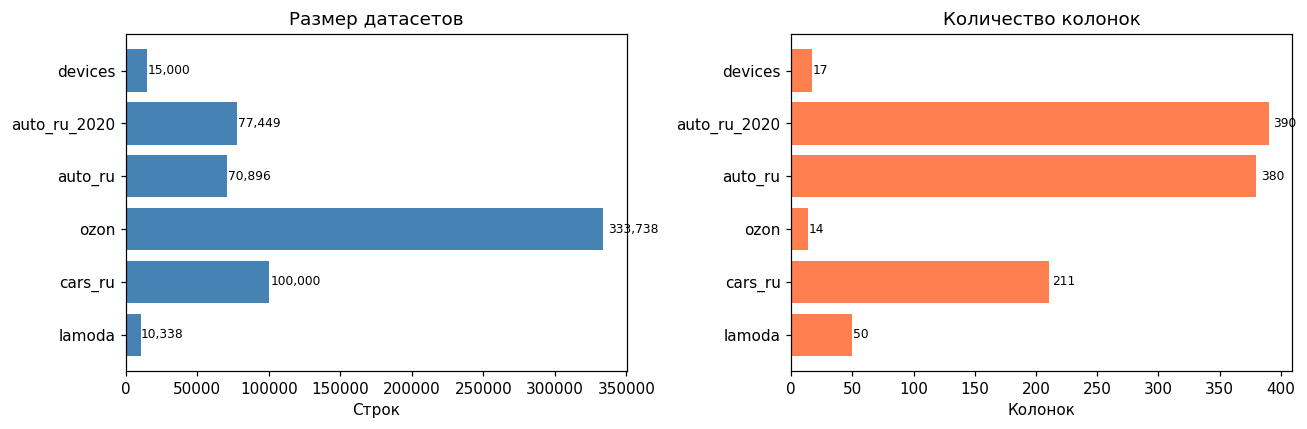

In [14]:
overview = pd.DataFrame([
    {
        'датасет': name,
        'строк': len(df),
        'колонок': len(df.columns),
        'null %': f"{df.isna().mean().mean():.1%}",
    }
    for name, df in dfs.items()
])
display(overview)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(overview['датасет'], overview['строк'], color='steelblue')
axes[0].set_xlabel('Строк')
axes[0].set_title('Размер датасетов')
for i, v in enumerate(overview['строк']):
    axes[0].text(v * 1.01, i, f'{v:,}', va='center', fontsize=8)

axes[1].barh(overview['датасет'], overview['колонок'], color='coral')
axes[1].set_xlabel('Колонок')
axes[1].set_title('Количество колонок')
for i, v in enumerate(overview['колонок']):
    axes[1].text(v * 1.01, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Качество natural labels

Для каждого датасета проверяем: дают ли потенциальные блокинг-ключи реальные дублированные сущности, или это мусор.

### 2.1 Lamoda — Title+Brand как ключ

**Гипотеза:** одинаковые Title+Brand = один товар.  
**Проверка:** если `about.Состав, %` различается у «дублей» — это разные товары.

In [15]:
lam = dfs['lamoda']
key = ['Title', 'Brand']
comp_col = next((c for c in lam.columns if 'состав' in c.lower()), None)
art_col  = next((c for c in lam.columns if 'артикул' in c.lower()), None)

print(f'Состав-колонка: {comp_col}')
print(f'Артикул-колонка: {art_col}')

groups = lam.dropna(subset=key).groupby(key)
dup_groups = {k: g for k, g in groups if len(g) >= 2}
n_pairs = sum(len(g) * (len(g) - 1) // 2 for g in dup_groups.values())
print(f'\nГрупп с ≥2 строками: {len(dup_groups)}')
print(f'Потенциальных пар:   {n_pairs:,}')

# False-positive rate: у «дублей» по Title+Brand различается ли состав?
if comp_col:
    fp_pairs = total_pairs = 0
    for _, g in dup_groups.items():
        vals = g[comp_col].fillna('').astype(str).tolist()
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                total_pairs += 1
                if vals[i] != vals[j]:
                    fp_pairs += 1
    fp_rate = fp_pairs / total_pairs if total_pairs else 0
    print(f'\nFalse-positive rate (разный состав): {fp_rate:.1%}')
    print('→ >10% = ключ Title+Brand слишком грубый')

# Артикул — насколько уникален?
if art_col:
    art_total = lam[art_col].dropna().count()
    art_uniq  = lam[art_col].dropna().nunique()
    art_fill  = art_total / len(lam)
    art_dup   = lam[art_col].dropna().duplicated(keep=False).sum()
    print(f'\nАртикул: заполнен={art_fill:.1%}, уникальных={art_uniq}/{art_total}, дублей={art_dup}')

Состав-колонка: about.Состав, %
Артикул-колонка: about.Артикул

Групп с ≥2 строками: 1698
Потенциальных пар:   23,665

False-positive rate (разный состав): 65.3%
→ >10% = ключ Title+Brand слишком грубый

Артикул: заполнен=99.8%, уникальных=10318/10318, дублей=0


In [16]:
# Примеры «дублей» по Title+Brand — показываем, что это разные товары
print('Примеры пар по Title+Brand:')
show_cols = [c for c in ['Title', 'Brand', 'Price', comp_col, art_col] if c and c in lam.columns]
shown = 0
for (title, brand), g in dup_groups.items():
    if shown >= 3:
        break
    print(f"\n  '{title}' / '{brand}' — {len(g)} строк")
    display(g[show_cols].head(3).reset_index(drop=True))
    shown += 1

Примеры пар по Title+Brand:

  'Белье корректирующее' / 'Alla Buone' — 3 строк


,Title,Brand,Price,"about.Состав, %",about.Артикул
0,Белье корректирующее,Alla Buone,509 ₽,"Полиамид - 90%, Эластан - 10%",MP002XW1C8VJ
1,Белье корректирующее,Alla Buone,680 ₽,"Полиамид - 80%, Эластан - 20%",MP002XW03458
2,Белье корректирующее,Alla Buone,756 ₽,"Полиамид - 90%, Эластан - 10%",MP002XW099U3



  'Белье корректирующее' / 'Gilmeeva' — 2 строк


,Title,Brand,Price,"about.Состав, %",about.Артикул
0,Белье корректирующее,Gilmeeva,1 870 ₽,"Полиэстер - 85%, Хлопок - 10%, Спандекс - 5%",XD001XW010DR
1,Белье корректирующее,Gilmeeva,1 870 ₽,"Полиэстер - 85%, Хлопок - 10%, Спандекс - 5%",XD001XW010DQ



  'Блуза' / 'Abitu' — 2 строк


,Title,Brand,Price,"about.Состав, %",about.Артикул
0,Блуза,Abitu,12 000 ₽,"Полиэстер - 75%, Шелк - 25%",MP002XW18FZ4
1,Блуза,Abitu,11 200 ₽,"Полиэстер - 75%, Шелк - 25%",MP002XW18FZI


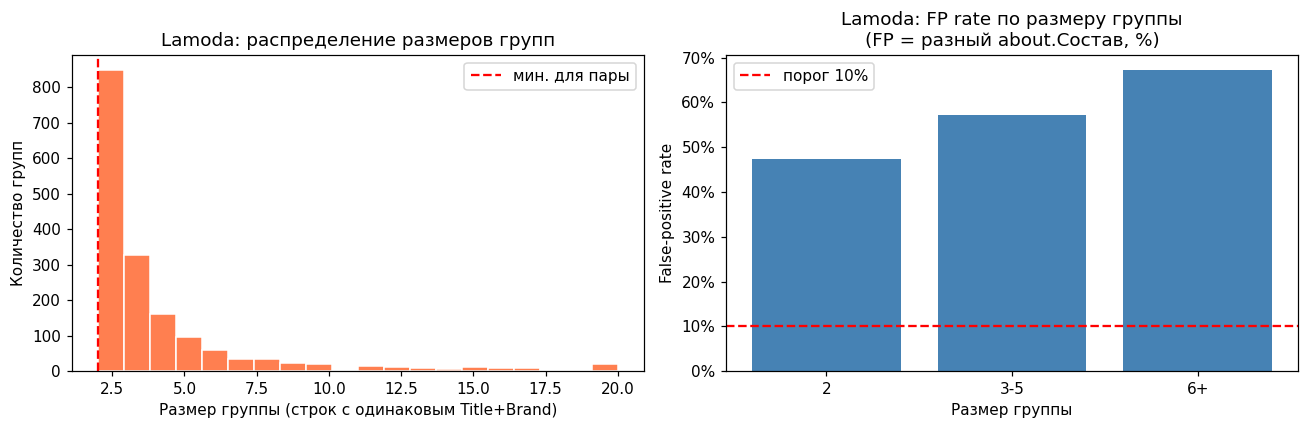

In [17]:
# Визуализация: распределение размеров групп Lamoda (по Title+Brand)
group_sizes = pd.Series([len(g) for g in dup_groups.values()])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(group_sizes.clip(upper=20), bins=20, color='coral', edgecolor='white')
axes[0].set_xlabel('Размер группы (строк с одинаковым Title+Brand)')
axes[0].set_ylabel('Количество групп')
axes[0].set_title('Lamoda: распределение размеров групп')
axes[0].axvline(2, color='red', linestyle='--', label='мин. для пары')
axes[0].legend()

if comp_col:
    # FP rate vs группы по размеру
    buckets = {2: 0, '3-5': 0, '6+': 0}
    counts  = {2: 0, '3-5': 0, '6+': 0}
    for _, g in dup_groups.items():
        key_b = 2 if len(g) == 2 else ('3-5' if len(g) <= 5 else '6+')
        vals = g[comp_col].fillna('').astype(str).tolist()
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                counts[key_b] += 1
                if vals[i] != vals[j]:
                    buckets[key_b] += 1
    fp_by_size = {k: (buckets[k] / counts[k] if counts[k] else 0) for k in buckets}
    axes[1].bar([str(k) for k in fp_by_size], list(fp_by_size.values()), color='steelblue')
    axes[1].set_xlabel('Размер группы')
    axes[1].set_ylabel('False-positive rate')
    axes[1].set_title(f'Lamoda: FP rate по размеру группы\n(FP = разный {comp_col})')
    axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
    axes[1].axhline(0.1, color='red', linestyle='--', label='порог 10%')
    axes[1].legend()

plt.tight_layout()
plt.show()

### 2.2 Ozon — URL-пары ('Ссылка на товар')

Один и тот же URL в разных месячных выгрузках = один товар в разные моменты времени.

In [18]:
ozon = dfs['ozon']
url_col = 'Ссылка на товар'
src_col = '__source_file'

url_counts = ozon[url_col].value_counts()
dup_urls = url_counts[url_counts >= 2]
n_pairs = int((dup_urls * (dup_urls - 1) // 2).sum())

print(f'Всего строк: {len(ozon):,}')
print(f'URL с ≥2 строками: {len(dup_urls):,}')
print(f'Потенциальных пар: {n_pairs:,}')
print(f'Файлов-источников: {ozon[src_col].nunique()}')
print(f'Файлы: {sorted(ozon[src_col].unique())}')

# cross-file vs same-file
cross = same = 0
for url, g in ozon[ozon[url_col].isin(dup_urls.index[:2000])].groupby(url_col):
    srcs = g[src_col].tolist()
    for i in range(len(srcs)):
        for j in range(i + 1, len(srcs)):
            if srcs[i] != srcs[j]:
                cross += 1
            else:
                same += 1

print(f'\nИз первых 2000 URL: cross-file={cross:,}, same-file={same:,}')
print(f'→ cross-file / total = {cross/(cross+same):.1%}')

Всего строк: 333,738
URL с ≥2 строками: 74,447
Потенциальных пар: 318,850
Файлов-источников: 34
Файлы: ['2021-07-12_opendata_datasetfavorites_2021-06-12_2021-07-11.xlsx', 'chto-dobavlyali-v-izbrannoe-v-dekabre-2020.xlsx', 'chto-dobavlyali-v-izbrannoe-v-noyabre-2020_2SSM2SO.xlsx', 'chto-dobavlyali-v-izbrannoe-v-yanvare-2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-06_02_2021-07_03_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-13_02_2021-14_03_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-16_01_2021-14_02_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-20_02_2021-21_03_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-23_01_2021-21_02_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-27_02_2021-28_03_2021.xlsx', 'chto-dobavlyali-v-izbrannoe_-30_01_2021-28_02_2021_4I3ycAJ.xlsx', 'chto-dobavlyaut-v-izbrannoe_-01_05_2021-30_05_2021.xlsx', 'chto-dobavlyaut-v-izbrannoe_-03_04_2021-02_05_2021.xlsx', 'chto-dobavlyaut-v-izbrannoe_-05_06_2021-04_07_2021.xlsx', 'chto-dobavlyaut-v-izbrannoe_-06_03_2021-04_04_2021.xlsx', 'chto-dobav

In [19]:
# Проверяем: различаются ли счётчики избранного у cross-file пар (= реальное изменение данных)
fav_cols = [c for c in ozon.columns if 'избранное' in c.lower()]
print(f'Колонки с избранным: {fav_cols}')

ex_url = dup_urls.index[0]
ex_g = ozon[ozon[url_col] == ex_url]
print(f'\nПример пары (URL={ex_url}):')
display(ex_g[[src_col] + fav_cols[:4]].reset_index(drop=True))

# Если счётчики одинаковы — это просто дубли одного файла, не реальная динамика
if fav_cols:
    fav_main = fav_cols[0]
    vary_rate = ozon[ozon[url_col].isin(dup_urls.index)].groupby(url_col)[fav_main].nunique().gt(1).mean()
    print(f'\nДоля URL где {fav_main!r} меняется: {vary_rate:.1%}')
    print('→ высокое значение = пары реально отличаются (разные моменты времени)')

Колонки с избранным: ['Количество добавлений в избранное, 30 дней', 'Количество добавлений в избранное, все время', 'Количество добавлений в избранное, декабрь 2020', 'Количество добавлений в избранное, ноябрь 2020', 'Количество добавлений в избранное, январь 2021']

Пример пары (URL=https://www.ozon.ru/product/150141112):


,__source_file,"Количество добавлений в избранное, 30 дней","Количество добавлений в избранное, все время","Количество добавлений в избранное, декабрь 2020","Количество добавлений в избранное, ноябрь 2020"
0,2021-07-12_opendata_datasetfavorites_2021-06-1...,411.0,2020-10-21,NaN,NaN
1,chto-dobavlyali-v-izbrannoe-v-dekabre-2020.xlsx,NaN,NaT,639.0,NaN
2,chto-dobavlyali-v-izbrannoe-v-noyabre-2020_2SS...,NaN,NaT,NaN,330.0
3,chto-dobavlyali-v-izbrannoe-v-yanvare-2021.xlsx,NaN,NaT,NaN,NaN
4,chto-dobavlyali-v-izbrannoe_-06_02_2021-07_03_...,393.0,NaT,NaN,NaN
5,chto-dobavlyali-v-izbrannoe_-13_02_2021-14_03_...,388.0,NaT,NaN,NaN
6,chto-dobavlyali-v-izbrannoe_-16_01_2021-14_02_...,443.0,NaT,NaN,NaN
7,chto-dobavlyali-v-izbrannoe_-20_02_2021-21_03_...,360.0,NaT,NaN,NaN
8,chto-dobavlyali-v-izbrannoe_-23_01_2021-21_02_...,385.0,NaT,NaN,NaN
9,chto-dobavlyali-v-izbrannoe_-27_02_2021-28_03_...,338.0,NaT,NaN,NaN



Доля URL где 'Количество добавлений в избранное, 30 дней' меняется: 95.6%
→ высокое значение = пары реально отличаются (разные моменты времени)


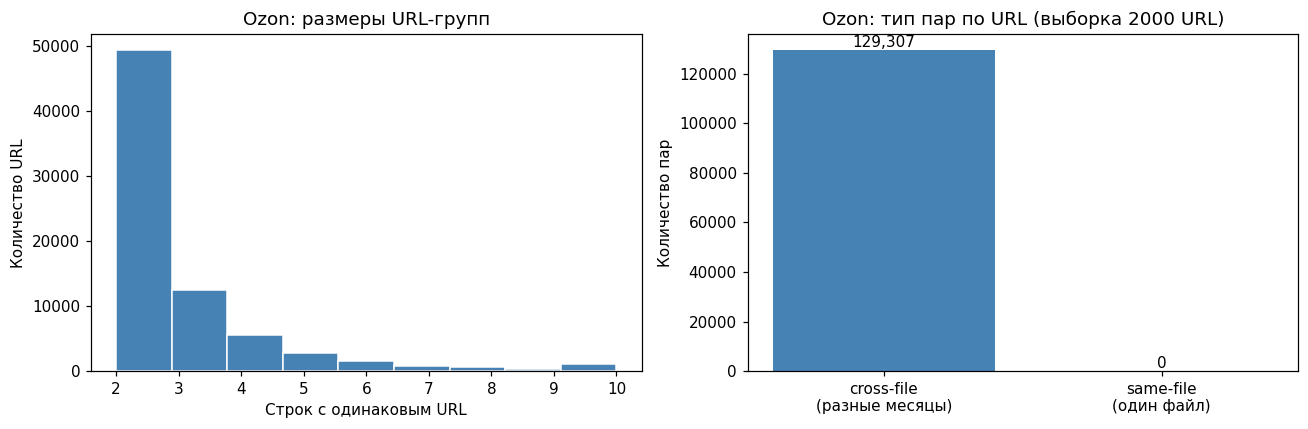

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение размеров URL-групп
axes[0].hist(url_counts[url_counts >= 2].clip(upper=10), bins=9, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Строк с одинаковым URL')
axes[0].set_ylabel('Количество URL')
axes[0].set_title('Ozon: размеры URL-групп')

# cross vs same file
axes[1].bar(['cross-file\n(разные месяцы)', 'same-file\n(один файл)'], [cross, same],
            color=['steelblue', 'coral'])
axes[1].set_ylabel('Количество пар')
axes[1].set_title('Ozon: тип пар по URL (выборка 2000 URL)')
for i, v in enumerate([cross, same]):
    axes[1].text(i, v + max(cross, same)*0.01, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

### 2.3 auto_ru × auto_ru_2020 — пары по sell_id

Два независимых скрейпа auto.ru разными людьми, с разными парсерами. Одинаковый `sell_id` = одно объявление.

auto_ru:        70,896 строк, 70,896 уникальных sell_id
auto_ru_2020:   77,449 строк, 75,790 уникальных sell_id
Overlap (пары): 16,955
  % от auto_ru:      23.9%
  % от auto_ru_2020: 22.4%
Только в auto_ru:      53,941
Только в auto_ru_2020: 58,835


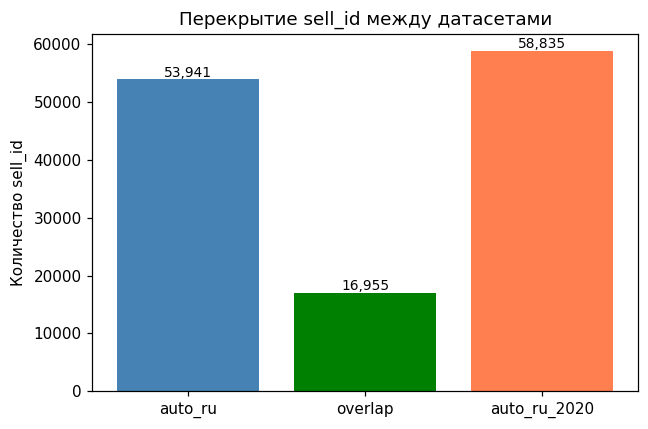

In [21]:
ar  = dfs['auto_ru']
ar2 = dfs['auto_ru_2020']

ids_a = set(ar['sell_id'].dropna().astype(str))
ids_b = set(ar2['sell_id'].dropna().astype(str))
overlap = ids_a & ids_b

print(f'auto_ru:        {len(ar):,} строк, {len(ids_a):,} уникальных sell_id')
print(f'auto_ru_2020:   {len(ar2):,} строк, {len(ids_b):,} уникальных sell_id')
print(f'Overlap (пары): {len(overlap):,}')
print(f'  % от auto_ru:      {len(overlap)/len(ids_a):.1%}')
print(f'  % от auto_ru_2020: {len(overlap)/len(ids_b):.1%}')
print(f'Только в auto_ru:      {len(ids_a - ids_b):,}')
print(f'Только в auto_ru_2020: {len(ids_b - ids_a):,}')

fig, ax = plt.subplots(figsize=(6, 4))
only_a = len(ids_a - ids_b)
only_b = len(ids_b - ids_a)
ov = len(overlap)
ax.bar(['auto_ru', 'overlap', 'auto_ru_2020'], [only_a, ov, only_b],
       color=['steelblue', 'green', 'coral'])
ax.set_ylabel('Количество sell_id')
ax.set_title('Перекрытие sell_id между датасетами')
for i, v in enumerate([only_a, ov, only_b]):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.4 Devices — проверка на синтетику

In [22]:
dev = dfs['devices']
model_col = 'device_model'

print('Примеры device_model:', dev[model_col].dropna().unique()[:8].tolist())
print('Примеры manufacturer:', dev['manufacturer'].dropna().unique()[:8].tolist() if 'manufacturer' in dev.columns else 'N/A')

if 'manufacturer' in dev.columns:
    mfr_per_model = dev.groupby(model_col)['manufacturer'].nunique()
    multi_mfr_rate = (mfr_per_model > 1).mean()
    print(f'\nДоля model_id с >1 производителем: {multi_mfr_rate:.1%}')
    print('→ >50% = одинаковый model_id встречается у разных производителей = синтетика')
    print('\nТоп примеров (одна модель, разные производители):')
    bad_models = mfr_per_model[mfr_per_model > 1].index[:3]
    for m in bad_models:
        g = dev[dev[model_col] == m][['device_model', 'manufacturer', 'release_year', 'device_type']]
        display(g.head(3).reset_index(drop=True))

Примеры device_model: ['ПРО-352', 'ВЕБ-192', 'ФЛЕ-665', 'МФУ-439', 'КОМ-564', 'СЕР-991', 'МОН-939', 'ГАР-202']
Примеры manufacturer: ['Lenovo', 'Logitech', 'HP', 'Epson', 'Dell', 'Samsung', 'Cisco', 'TP-Link']

Доля model_id с >1 производителем: 37.3%
→ >50% = одинаковый model_id встречается у разных производителей = синтетика

Топ примеров (одна модель, разные производители):


,device_model,manufacturer,release_year,device_type
0,IP--104,Logitech,2022,IP Phone
1,IP--104,Dell,2010,IP Phone


,device_model,manufacturer,release_year,device_type
0,IP--106,Logitech,2014,IP Phone
1,IP--106,ASUS,2005,IP Phone


,device_model,manufacturer,release_year,device_type
0,IP--114,Cisco,2011,IP Phone
1,IP--114,HP,2017,IP Phone
2,IP--114,Dell,2009,IP Phone


### 2.5 cars_ru — поиск natural pairs

In [23]:
cars = dfs['cars_ru']

vin_col = next((c for c in cars.columns if 'vin' in c.lower()), None)
print(f'VIN колонка: {vin_col or "не найдена"}')

# Дубли по description/url
for col in ('description', 'url', 'link'):
    if col in cars.columns:
        n = cars[col].dropna().count()
        d = cars[col].dropna().duplicated(keep=False).sum()
        print(f'{col}: дублей {d}/{n} ({d/n:.1%})')

# Блокинг brand+model+year: считаем пары
key_cols = [c for c in ['mark', 'model', 'year'] if c in cars.columns]
gs = cars.groupby(key_cols).size()
n_groups_dup = (gs >= 2).sum()
n_pairs = int(sum(s * (s - 1) // 2 for s in gs if s >= 2))
n_large = (gs > 50).sum()
print(f'\nБлокинг {" + ".join(key_cols)}: групп={len(gs)}, дубль-групп={n_groups_dup}, '
      f'больших(>50)={n_large}')
print(f'Пар-кандидатов: {n_pairs:,} — слишком много для реальных дублей')
print('→ без VIN натуральных пар нет; только синтетика')

VIN колонка: не найдена
description: дублей 2468/94298 (2.6%)

Блокинг mark + model + year: групп=11816, дубль-групп=7889, больших(>50)=333
Пар-кандидатов: 2,114,493 — слишком много для реальных дублей
→ без VIN натуральных пар нет; только синтетика


---
## 3. Расхождения форматов в реальных парах (auto_ru × auto_ru_2020)

Для каждой общей колонки: в каком % matched пар значение отличается?  
Это показывает, насколько сложна задача ER — и какие колонки «вносят шум».

In [24]:
# Дедупликация по sell_id (могут быть дубли внутри датасета)
def _make_idx(df):
    d = df.copy()
    d['sell_id'] = d['sell_id'].astype(str)
    return d.drop_duplicates('sell_id').set_index('sell_id')

ar_idx  = _make_idx(ar)
ar2_idx = _make_idx(ar2)
common_ids = ar_idx.index.intersection(ar2_idx.index)

# Берём выборку для скорости
N_SAMPLE = min(len(common_ids), 5000)
sample_ids = common_ids[:N_SAMPLE]

# sell_id теперь индекс — исключаем его из колонок
common_cols = [c for c in ar.columns if c in ar2.columns and c != 'sell_id']
print(f'Matched пар: {len(common_ids):,}')
print(f'Общих колонок (без sell_id): {len(common_cols)}')
print(f'Выборка для анализа: {N_SAMPLE}')

a_vals = ar_idx.loc[sample_ids, common_cols]
b_vals = ar2_idx.loc[sample_ids, common_cols]

divergence = {}
for col in common_cols:
    a = a_vals[col].fillna('__NA__').astype(str).values
    b = b_vals[col].fillna('__NA__').astype(str).values
    divergence[col] = (a != b).mean()

div_series = pd.Series(divergence).sort_values(ascending=False)

print(f'\nКолонки где пары ВСЕГДА совпадают (diff=0%): {(div_series == 0).sum()}')
print(list(div_series[div_series == 0].index[:10]))
print(f'\nКолонки где >90% пар расходятся: {(div_series > 0.9).sum()}')

Matched пар: 16,955
Общих колонок (без sell_id): 365
Выборка для анализа: 5000

Колонки где пары ВСЕГДА совпадают (diff=0%): 170
['brand', 'fuelType', 'vendor', 'Привод', 'model_info.code', 'model_info.name', 'model_info.ru_name', 'super_gen.engine_type', 'model_name', 'equip_PRA']

Колонки где >90% пар расходятся: 8


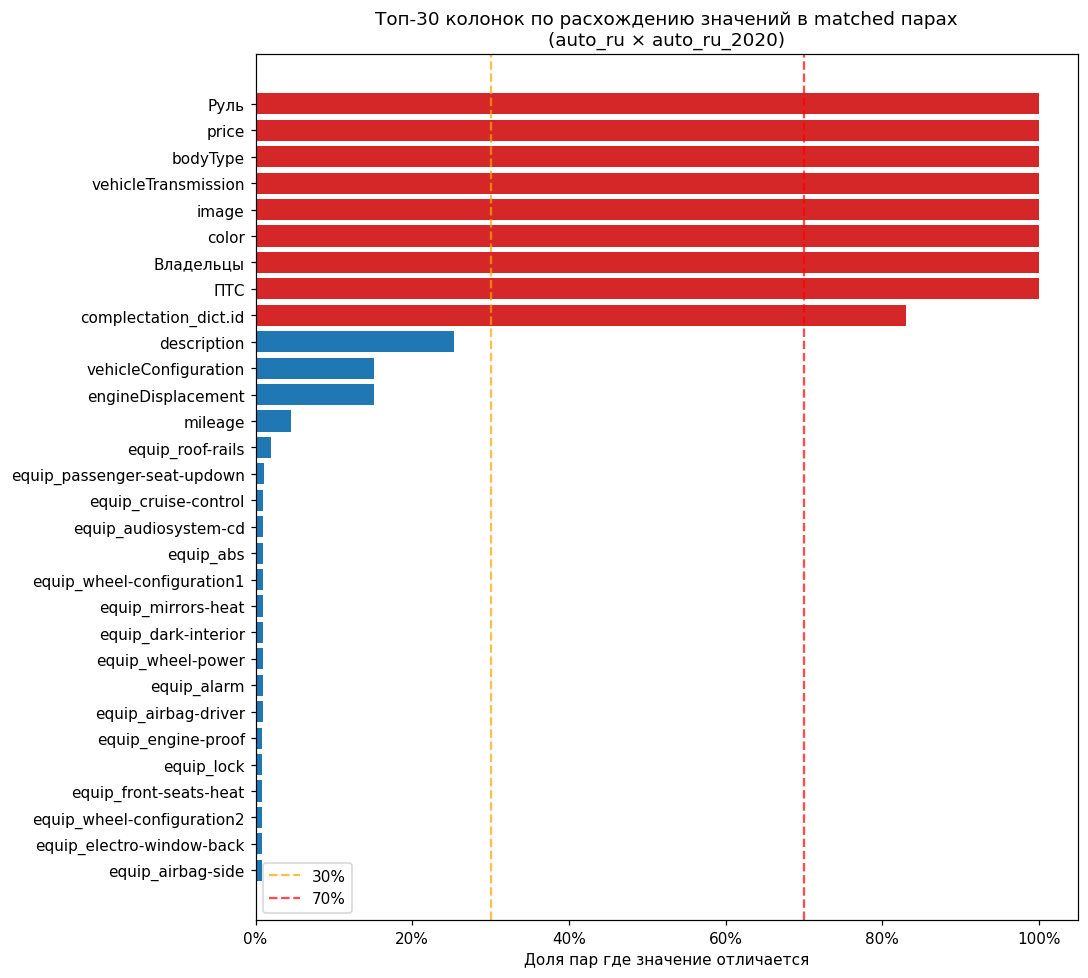

In [25]:
# График: топ-30 колонок по divergence
top30 = div_series.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#d62728' if v > 0.7 else '#ff7f0e' if v > 0.3 else '#1f77b4' for v in top30.values]
bars = ax.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1])
ax.set_xlabel('Доля пар где значение отличается')
ax.set_title('Топ-30 колонок по расхождению значений в matched парах\n(auto_ru × auto_ru_2020)')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='30%')
ax.axvline(0.7, color='red', linestyle='--', alpha=0.7, label='70%')
ax.legend()
plt.tight_layout()
plt.show()

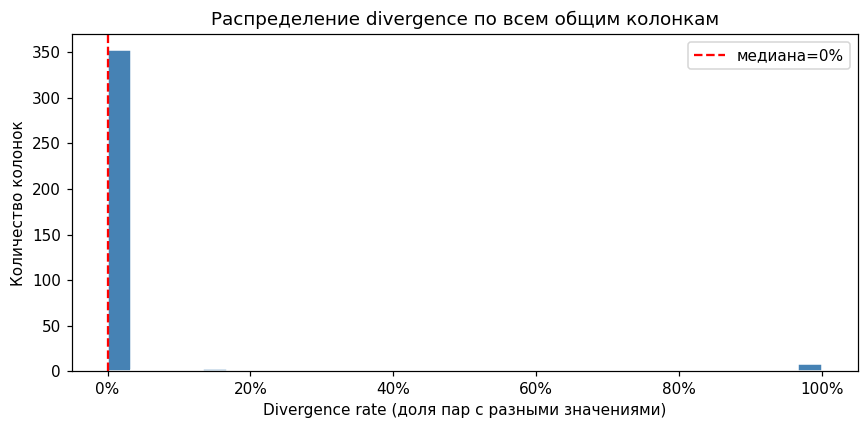

Медиана divergence: 0.1%
Колонок с div=0% (идентичны): 170
Колонок с div>50%: 9


In [26]:
# Распределение divergence по всем колонкам (гистограмма)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(div_series.values, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Divergence rate (доля пар с разными значениями)')
ax.set_ylabel('Количество колонок')
ax.set_title('Распределение divergence по всем общим колонкам')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.axvline(div_series.median(), color='red', linestyle='--',
           label=f'медиана={div_series.median():.0%}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Медиана divergence: {div_series.median():.1%}')
print(f'Колонок с div=0% (идентичны): {(div_series == 0).sum()}')
print(f'Колонок с div>50%: {(div_series > 0.5).sum()}')

In [27]:
# Детальные примеры расхождений в семантических колонках
key_semantic = ['bodyType', 'color', 'engineDisplacement', 'brand', 'mileage', 'year',
                'fuelType', 'transmission', 'enginePower']
key_semantic = [c for c in key_semantic if c in common_cols]

print('Примеры расхождений (5 пар):')
print(f"{'Колонка':<30} {'auto_ru':<35} {'auto_ru_2020':<35}")
print('-' * 100)
for sid in list(sample_ids[:5]):
    print(f'\n  sell_id={sid}')
    for col in key_semantic:
        v_a = ar_idx.loc[sid, col] if sid in ar_idx.index else '—'
        v_b = ar2_idx.loc[sid, col] if sid in ar2_idx.index else '—'
        marker = ' !!!' if str(v_a) != str(v_b) else '    '
        print(f'{marker} {col:<28} {str(v_a):<35} {str(v_b):<35}')

Примеры расхождений (5 пар):
Колонка                        auto_ru                             auto_ru_2020                       
----------------------------------------------------------------------------------------------------

  sell_id=1100165896
 !!! bodyType                     лифтбек                             Лифтбек                            
 !!! color                        белый                               FAFBFB                             
     engineDisplacement           1.6                                 1.6                                
     brand                        SKODA                               SKODA                              
     mileage                      226706                              226706                             
     fuelType                     бензин                              бензин                             
     enginePower                  102.0                               102.0                              

  

---
## 4. sell_id Leakage

In [28]:
sid_uniq_a = ar['sell_id'].nunique() / len(ar)
sid_uniq_b = ar2['sell_id'].nunique() / len(ar2)

print('sell_id присутствует как обычная колонка в обоих датасетах.')
print(f'Уникальность sell_id: auto_ru={sid_uniq_a:.1%}, auto_ru_2020={sid_uniq_b:.1%}')
print()
print('Если оставить sell_id в признаках → GNN учит матчить по нему напрямую.')
print('Это trivial leakage: модель не нужна — достаточно string match.')
print()

# sell_id совпадает в парах по построению (мы отбирали intersection)
# Показываем несколько значений для наглядности
print('Примеры sell_id в matched парах:')
for sid in list(sample_ids[:5]):
    v_a = ar[ar['sell_id'].astype(str) == sid]['sell_id'].iloc[0]
    v_b = ar2[ar2['sell_id'].astype(str) == sid]['sell_id'].iloc[0]
    print(f'  auto_ru: {v_a}  |  auto_ru_2020: {v_b}  → совпадает: {str(v_a) == str(v_b)}')

print()
print('>>> Решение: sell_id ДРОПАТЬ из признаков перед построением графа.')
print('    Использовать sell_id только как ключ для создания лейблов (match/non-match).')

sell_id присутствует как обычная колонка в обоих датасетах.
Уникальность sell_id: auto_ru=100.0%, auto_ru_2020=97.9%

Если оставить sell_id в признаках → GNN учит матчить по нему напрямую.
Это trivial leakage: модель не нужна — достаточно string match.

Примеры sell_id в matched парах:
  auto_ru: 1100165896  |  auto_ru_2020: 1100165896  → совпадает: True
  auto_ru: 1100768262  |  auto_ru_2020: 1100768262  → совпадает: True
  auto_ru: 1101117342  |  auto_ru_2020: 1101117342  → совпадает: True
  auto_ru: 1101179448  |  auto_ru_2020: 1101179448  → совпадает: True
  auto_ru: 1101111488  |  auto_ru_2020: 1101111488  → совпадает: True

>>> Решение: sell_id ДРОПАТЬ из признаков перед построением графа.
    Использовать sell_id только как ключ для создания лейблов (match/non-match).


---
## 5. Column presence divergence — какие колонки «выпадают»

Для общих колонок: в каком % matched пар одна сторона NULL, другая — нет?  
Это «естественный column dropout» — целевое поведение, которое мы будем симулировать в синтетике.

In [29]:
only_a_cols = sorted(set(ar.columns) - set(ar2.columns))
only_b_cols = sorted(set(ar2.columns) - set(ar.columns))
print(f'Колонок только в auto_ru ({len(only_a_cols)}): {only_a_cols[:15]}')
print(f'\nКолонок только в auto_ru_2020 ({len(only_b_cols)}): {only_b_cols[:15]}')

# Null-divergence: одна сторона NULL, другая нет
null_div = {}
for col in common_cols:
    a_null = a_vals[col].isna()
    b_null = b_vals[col].isna()
    null_div[col] = (a_null != b_null).mean()

nd_series = pd.Series(null_div).sort_values(ascending=False)
print(f'\nКолонок с одностронним null в >50% пар: {(nd_series > 0.5).sum()}')
print(f'Медиана null-divergence: {nd_series.median():.1%}')

Колонок только в auto_ru (14): ['car_url', 'equip_24-inch-wheels', 'equip_8RM', 'equip_E0P', 'equip_PQ5', 'equip_WVA', 'is_train', 'parsing_unixtime', 'priceCurrency', 'super_gen.price_segment', 'super_gen.ru_name', 'super_gen.year_from', 'super_gen.year_to', 'Владение']

Колонок только в auto_ru_2020 (24): ['equip_033GQ', 'equip_033IN', 'equip_041CZ', 'equip_066AC', 'equip_086EG', 'equip_086FA', 'equip_086GC', 'equip_211', 'equip_414', 'equip_68BD', 'equip_68BF', 'equip_GCD', 'equip_JPM', 'equip_PA1', 'equip_RC4']

Колонок с одностронним null в >50% пар: 1
Медиана null-divergence: 0.0%


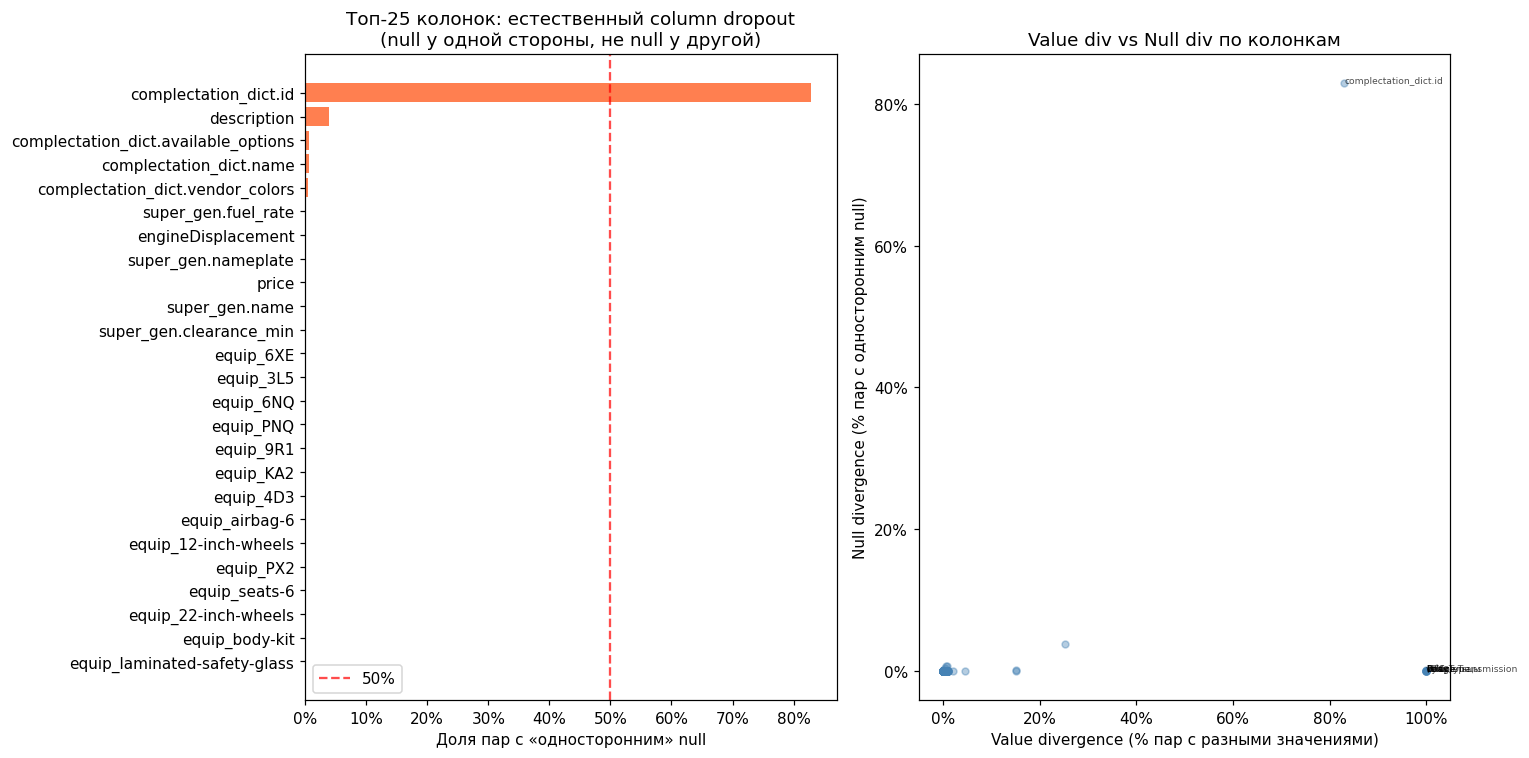

In [30]:
top_nd = nd_series.head(25)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Топ null-divergence колонок
axes[0].barh(top_nd.index[::-1], top_nd.values[::-1], color='coral')
axes[0].set_xlabel('Доля пар с «односторонним» null')
axes[0].set_title('Топ-25 колонок: естественный column dropout\n(null у одной стороны, не null у другой)')
axes[0].xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='50%')
axes[0].legend()

# Сравнение: value divergence vs null divergence (scatter)
shared = sorted(set(div_series.index) & set(nd_series.index))
x = [div_series[c] for c in shared]
y = [nd_series[c] for c in shared]
axes[1].scatter(x, y, alpha=0.4, s=20, color='steelblue')
axes[1].set_xlabel('Value divergence (% пар с разными значениями)')
axes[1].set_ylabel('Null divergence (% пар с односторонним null)')
axes[1].set_title('Value div vs Null div по колонкам')
axes[1].xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

# Подписываем выбросы
for c in shared:
    vd, nd = div_series[c], nd_series[c]
    if vd > 0.7 or nd > 0.5:
        axes[1].annotate(c, (vd, nd), fontsize=6, alpha=0.7)

plt.tight_layout()
plt.show()

---
## 6. ИТОГ — план лейблов и синтетики

| Датасет | Natural labels | Вывод |
|---|---|---|
| **auto_ru × auto_ru_2020** | sell_id overlap ~17k | **ВАЛИДНЫ.** `sell_id` дропать из признаков. |
| **ozon** | URL cross-file пары | Условно валидны: один продукт, разные месяцы. Счётчики различаются. |
| **lamoda** | Title+Brand → МУСОР | Высокий FP rate (разный состав). Артикул — проверить. Скорее всего — только синтетика. |
| **cars_ru** | нет (нет VIN) | Только синтетика. |
| **devices** | СИНТЕТИКА (model_id не уникален) | Выбросить из natural labels. Только синтетика. |

**Следующий шаг — `04_synth_pairs.py`:**

- **Real positives:** auto_ru × auto_ru_2020 sell_id пары (`sell_id` дропается из признаков)
- **Ozon:** cross-file URL пары (если счётчики различаются — берём)
- **Synthetic:** lamoda, cars_ru, devices → N «поставщиков» через `column_dropout` + синонимы имён колонок + `value_corruption`
- **Negatives:** random пары из разных entities (разные brand+model+year для авто)